# Nowcasting Prediction Tutorial

We have just spent some time understanding how autoencoders work, and understanding the TemporalWindow pipeline step. In this example we combine a temporal window with our previous example to form a basic prediction architecture. This simple architecture could be used autoregressively to predict farther out into the future than a single time step.

We also introduce saving and loading of model weights in this tutorial, plus the use of batching to speed up training. Prediction models are harder to train than AutoEncoders, so it is more likely you will want to train for more steps or perform more experiments.

This tutorial trains a "blurry predictor". This is a common problem when setting out on new ML problems. Various "fixes" to this issue of blurriness have been found in the literature, but to my knowledge nobody has isolated a single cause, as all examples have pursued multiple improvements in parallel. It would be more interesting scientifically to perform ablation studies to get to the crux of the practises needed to avoid this. 

As a model developer, you will have multiple choices. 

Rather than working 'bottom up', you could go straight to a known architecture, and vary it to match your problem space. If that works and is not computationally prohibitive, then starting with a known-good state isn't a bad idea. The risk is that you might not know *why* the model is effective, and then hit a scientific dead-end if you need to make major changes. Another risk is that it may be more computationally intensive than required. On the other hand, maybe it's great, and maybe you like the idea of innovating something pre-existing. Future tutorial series will be developed to show how to integrate a variety of "named model" architectures.

Alternatively, you can start to work through extensions in a systematic fashion, building up your knowledge-base on what is effective for your area of science, starting with small and simple networks that are cheap to train, and progressing to more complex and larger architectures from a solid footing. This may be slower, and does not offer the immediate satisfaction of a strong start, but potentially allows a more nuanced approach.

The choice is entirely up to you. Now, on with the show...

In [47]:
# Core Python imports
import datetime
import functools
import os
import warnings
warnings.filterwarnings('ignore')

In [48]:
# Scientific standard imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [49]:
# PyEarthTools imports including NCI cached data
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
from pyearthtools.data.time import Petdt

my_site = 'site_archive_nci'  # set this to 'site_archive_nci', 'site_archive_jasmin' or 'site_archive_met_office'
import importlib
_ = importlib.import_module(my_site)

In [50]:
# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim

# Set random seed for reproducibility
torch.manual_seed(42)

# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Detected device {device}, will attempt to use for training")

Detected device cuda:0, will attempt to use for training


## Load and prepare data

We will jump straight to the nearly same pipeline as previous examples.

In [51]:
# We specify the date, hour, and minute for querying data
selected_date = '20210609T02:00'

In [52]:
himawari = petdata.archive.Himawari('surface_global_irradiance')

# We will try to predict one-hour jumps
temporal_window = petpipe.modifications.TemporalWindow(
    prior_indexes=[-1], 
    posterior_indexes=[0], 
    merge_method = functools.partial(xr.concat, dim='time'),
    timedelta=petdata.time.TimeDelta((20, "minutes"))
)

training_split = petpipe.iterators.DateRange('20200101T00', '20210101T00', interval='10 minutes')

In [53]:
xarray_steps = petpipe.Pipeline(
    himawari,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(1200),
    temporal_window,
    iterator=training_split,
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError    
)

numpy_conversion = petpipe.Pipeline(
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=training_split,
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

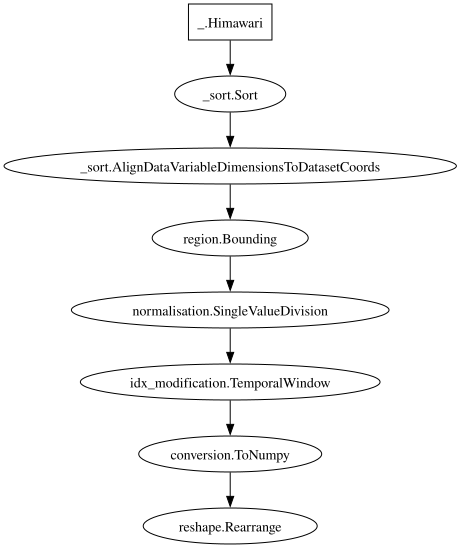

In [54]:
fullsat = xarray_steps + numpy_conversion
fullsat

In [55]:
prior, posterior = xarray_steps[selected_date]
prior

<xarray.Dataset> Size: 2MB
Dimensions:                    (time: 1, latitude: 501, longitude: 601)
Coordinates:
  * time                       (time) datetime64[ns] 8B 2021-06-09T01:40:00
  * latitude                   (latitude) float32 2kB -35.0 -34.98 ... -25.0
  * longitude                  (longitude) float32 2kB 138.0 138.0 ... 150.0
Data variables:
    surface_global_irradiance  (time, latitude, longitude) float64 2MB dask.array<chunksize=(1, 501, 601), meta=np.ndarray>
Attributes: (12/58)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    project:                          Gridded Solar Observations
    history:                          Mon Mar  4 01:55:07 2024: ncatted -a re...
    references:                       Poulsen C., Majewski L. J. (2022) Gridd...
    NCO:                              netCDF Operators version 4.7.7 (Homepag...

In [56]:
fullsat[selected_date][0]

array([[[[0.30995   , 0.29618333, 0.169225  , ..., 0.31699167,
          0.18884167, 0.22630833],
         [0.34205   , 0.34211667, 0.30593333, ..., 0.21483333,
          0.21483333, 0.30964167],
         [0.342375  , 0.34243333, 0.34249167, ..., 0.33324167,
          0.34355   , 0.34355   ],
         ...,
         [0.569325  , 0.5694    , 0.569475  , ..., 0.592525  ,
          0.59100833, 0.58954167],
         [0.569675  , 0.56969167, 0.56978333, ..., 0.59188333,
          0.59006667, 0.58955833],
         [0.569675  , 0.56969167, 0.56978333, ..., 0.59071667,
          0.58951667, 0.58944167]]]], shape=(1, 1, 501, 601))

### Data Exploration
Lets take a look at what the dataset contains. For this purpose we will create a smaller pipeline that keeps the data in xarray for easier plotting.

In [57]:
pairwise_iterator = iter(fullsat)  # Make an iterator to walk the time period
pairwise_iterator

<generator object Pipeline.__iter__ at 0x14f3cd773810>

## Training a machine learning model
Now that we have loaded and prepared the data, we can train a machine learning model on the data using the pipeline to feed the data into the training algorithm. In this example we will use an autoencoder, which is an example of unsupervised training as we don't need to label the data.

### Define the Prediction architecture
Here we define a predictive model. This is exactly like the autoencoder, in that it puts the input through a bottleneck layer. However, the training target is the next time step rather than the same as the input conditions. We will call the class "EncoderDecoder". Be aware, there are many more complex model architectures which are better-again-suited to the task of prediction, such as a U-Net. A major difference between this model an a U-Net is skip connections. You might wish to experiment with replacing this architecture wityh a U-Net architecture to improve performance.

In [12]:
# Reminder, the image size is latitude: 1726, longitude: 2214

class EncoderDecoder(nn.Module):
    def __init__(self, 
                 input_height = 501,
                 input_width = 601,
                 kernel_size = 4,
                 stride=2,
                 input_channel_count = 2,
                 output_channel_count = 2,
                 latent_dim=300):
        super(EncoderDecoder, self).__init__()

        self.input_width = input_width
        self.input_height = input_height
        self.input_channel_count = input_channel_count
        self.output_channel_count = output_channel_count

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=self.input_channel_count, out_channels=16, kernel_size=kernel_size, stride = stride, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride =stride, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=7),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=7),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=stride, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16, out_channels=self.output_channel_count, kernel_size=kernel_size, stride=stride, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        

    def forward(self, x):

        # Get latent representation
        latent = self.encoder(x)

        # Reconstruct input
        reconstructed = self.decoder(latent)

        return reconstructed

In [13]:
import collections
class Batched:
    '''
    A quick class to batch samples for the tutorial. PyTorch magically understands batches, and will interpret the first 
    axis (zeroth) as the batch dimension if you tell it to use a batch size.

    This class wraps a singleton iterator and provides a batched iterator over the same sequence.
    '''

    def __init__(self, singleton_iterator, batch_size=4):
        self.b = batch_size
        self.it = singleton_iterator

    def __iter__(self):        
        return self

    def __next__(self):

        try:
            members = tuple([next(self.it) for i in range(self.b)])
            batch = list(zip(*members))
            batch_xs = np.concatenate(batch[0])
            batch_ys = np.concatenate(batch[1])
            
            return (batch_xs, batch_ys)
        except:
            raise StopIteration()

### Prediction from untrained EncoderDecoder - and an aside on CPUs and GPUs
Here we revisit how if we make a prediction before training, using randomly initialised weights, we get noise out. This informs intuition on how machine learning works - by comparing poor predictions to the expected outputs, and iteratively solving towards an effective network.

These code snippets also demonstrate how we move the data into the GPU memory in order to do inference on the GPU, and then move it back to the CPU to analyse it further. In some architectures, the model layers are even split across CPU and GPU to make maximum use of GPU memory for high-cost layer calculations.

### Train the predictor
Now we define the training loop function and run the training. 

1000 samples is taking about 2 minutes It should be able to go much much much faster, but still we can test it and make progress. Let's to 30 minutes of training, i.e. 15k samples

In [16]:



def train(model=None, debug=False, num_epochs=6, max_samples= 100, print_per = 500, batch_size=16, cached=True, keepGoing=False):
    filename = 'predictor.ptch'

    # Initialize untrainted model and move to device
    model = EncoderDecoder(input_channel_count=1, output_channel_count=1).to(device)    

    # Load cached weights, biases and gradients if available
    if cached:
        if os.path.exists(filename):
            print("Found pre-existing cached model, using pretrained values")
            state_dict = torch.load(filename)
            model.load_state_dict(state_dict)

            # Return saved values if additional training not requested
            if not keepGoing:
                return model

    # Perform additional training (on untrained or pretrained model)
    model_update = train_loop(model, debug=debug, num_epochs=num_epochs, batch_size=batch_size, max_samples=max_samples, print_per=print_per)

    if cached==True:
        torch.save(model_update.state_dict(), filename)  # save the whole state dict so training can be results
    return model_update


def train_loop(model, *, debug, num_epochs, max_samples, batch_size, print_per):
    """
    Main Training loop Function
    """
    sample_ix = 0 

    # Loss function and optimizer
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)    
    print(f"Commencing training with model on {next(model.parameters()).device}", flush=True)
    
    for epoch in range(num_epochs):
        print(f'current epoch {epoch+1}', flush=True)
        total_loss = 0    
        epoch_samples = 0

        # Iterator is reset each epoch (walk again from the start)
        training_iterator = iter(Batched(iter(fullsat), batch_size=batch_size))  # Make an iterator to walk the time period
    
        while True:
            try:
                # Here we get an input-output pair, not just a single sample
                prior, posterior = next(training_iterator)
            except StopIteration:
                print('stop')
                break  # advance the epoch loop
            except:
                print('error - general')
                pass # some samples are just missing
    
            sample_ix += batch_size
            epoch_samples += batch_size
            if epoch_samples % print_per == 0:
                print(epoch_samples, flush=True)
            
            if sample_ix > max_samples:
                print('exceeded max samples', flush=True)
                break

            if debug:
                print(sample_ix, flush=True)

            # It is common to use 'x' for the input and capital "Y" for expected output
            x = torch.from_numpy(prior).float().to(device)   
            Y = torch.from_numpy(posterior).float().to(device)   

            if torch.any(torch.isnan(x)):
                # Skip nan inputs, they break the training
                if debug:
                    print('skipping nans')
                continue
    
            optimizer.zero_grad()
    
            # Forward pass prediction from the x values
            y = model.forward(x)

            # Calculate loss against the forward time step values
            loss = criterion(Y, y)
    
            # Backward pass and optimize      

            if debug:
                print(f"Calculated loss: {loss}", flush=True) 
        
                if torch.any(torch.isnan(loss)):
                    print("nan present in loss")
            

            # Don't progress training with NaNs in the loss
            if not torch.any(torch.isnan(loss)):
                total_loss += loss.item()
                loss.backward()
                optimizer.step()                
    
        # Print epoch statistics
        if epoch_samples != 0:
            avg_loss = total_loss / epoch_samples
            print(f'Epoch [{epoch+1}/{epoch_samples}], Average Loss: {avg_loss:.4f}')
        else:
            print('no samples processed this epoch')

    return model  # Note this will have been updated in-place

In [17]:
%%time

# Takes around 35 minutes, mostly due to slow data loading. Optimising the data loaders would be useful future work.

# Notes - try doing 150 samples with debug=True to see what's going on in the loop
# 8 or less is a reasonable batch size - try making it better and smaller over 150 samples to see what changes
# The max_samples and num_epochs below is fairly large, but prediction is a hard problem.
# Ideally, we would log validation performance each epoch and see how rapidly the model converges to guide the 
# decision on the number of samples needed to fit for the data, but that is out of scope here

trained_model = train(debug=False, num_epochs=3, max_samples= 10 * 1000, print_per = 500, batch_size=8, cached=True, keepGoing=True)

Commencing training with model on cuda:0
current epoch 1
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
exceeded max samples
Epoch [1/10008], Average Loss: 0.0055
current epoch 2
exceeded max samples
Epoch [2/8], Average Loss: 0.0000
current epoch 3
exceeded max samples
Epoch [3/8], Average Loss: 0.0000
CPU times: user 25min 52s, sys: 4min 37s, total: 30min 29s
Wall time: 35min 29s


### Make predictions and Evaluating Outputs
Once the model is trained, we now make predictions and evaluate the model.

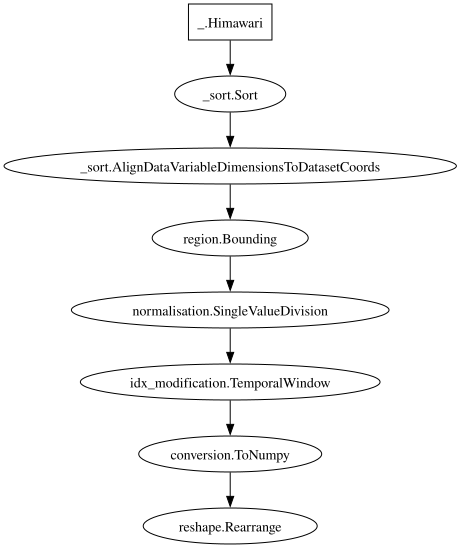

In [18]:
xarray_steps_val = petpipe.Pipeline(
    himawari,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(1200),
    temporal_window,
    iterator=petpipe.iterators.DateRange('20210201T00', '20210401T00', interval='20 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError    
)

numpy_conversion_val = petpipe.Pipeline(
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('20210201T00', '20210401T00', interval='20 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

fullsat_validate = xarray_steps_val + numpy_conversion_val
fullsat_validate


In [44]:
validate_iterator = iter(fullsat_validate)

# Visualising results

A picture is definitely worth a thousand loss function. We can immediately see here the model is struggling to produce a high-quality image. We know from our previous work that the difficulty is *not* image reconstruction - something we would be unsure about if we hadn't taken the step of producing an autoencoder with reasonable results. We can therefore isolate the issue to predictive skill. There are some genuine questions to answer here, and a lot of possible ways forward. Which will you choose?

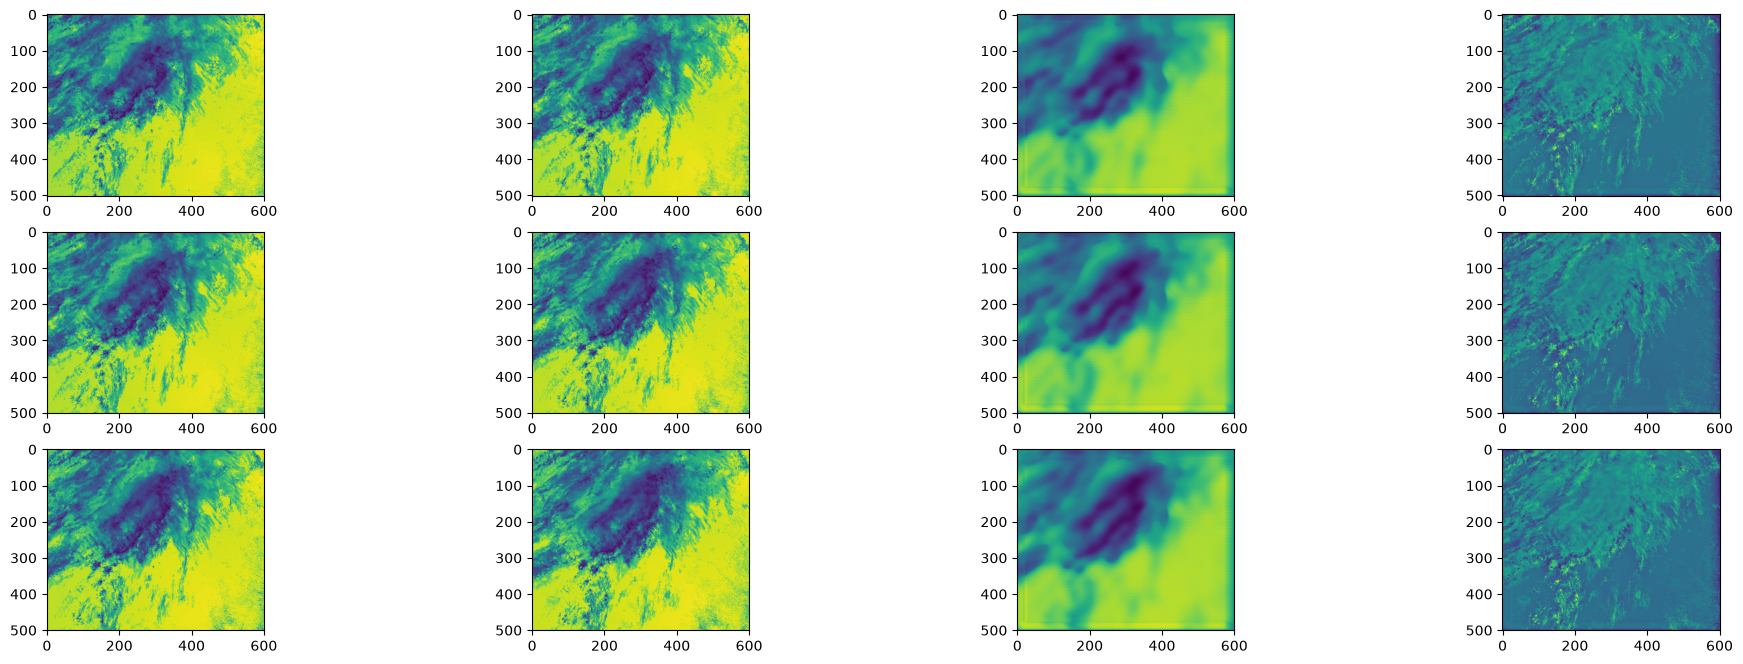

In [46]:
fig1 = plt.figure('sidebyside_satellite', figsize=(24,8))

rows = 3
cols = 4
for sample_index in range(rows):
    prior_sample, expected_result = next(validate_iterator)  # Get sample for plotting

    # Plot time t=0 in column 1 and time t=1 in column 2
    row_start = sample_index * cols
    ax1 = fig1.add_subplot(rows,cols,row_start+1)
    ax1.imshow(prior_sample[0,0])    
    ax1 = fig1.add_subplot(rows,cols,row_start+2)
    ax1.imshow(expected_result[0,0])    

    # Generate model prediction 
    prior_gpu = torch.from_numpy(prior_sample).float().to(device)
    prediction_gpu = trained_model.forward(prior_gpu)
    prediction_cpu = prediction_gpu.to('cpu').detach().numpy()
    error = prediction_cpu - expected_result

    # Plot model prediction in column 3 and error in column 4
    ax1 = fig1.add_subplot(rows,cols,row_start+3)
    ax1.imshow(prediction_cpu[0,0])
    ax1 = fig1.add_subplot(rows,cols,row_start+4)
    ax1.imshow(error[0][0])    

# Calculate scores for predictions
In order to evaluate the model performance, we need to use some metrics that capture different aspects of accuracy. Since we are generating images, we will use various state of the art image-related metrics. 

Furthe reading:
* [Guide to metrics for images generated by ML models](https://huggingface.co/blog/PrunaAI/objective-metrics-for-image-generation-assessment)
* torch metrics
   * [Structural Similarity Index](https://lightning.ai/docs/torchmetrics/stable/image/structural_similarity.html) - Aiming to measure how well the image strcuture is captured
   * [RMSE Sliding Window](https://lightning.ai/docs/torchmetrics/stable/image/root_mean_squared_error_using_sliding_window.html)Look at RMSE, but not just point by point

In [21]:
import torchmetrics.image

In [22]:
ssi_metric = torchmetrics.image.StructuralSimilarityIndexMeasure()

In [23]:
rmse_sw_metric = torchmetrics.image.RootMeanSquaredErrorUsingSlidingWindow()

In [25]:
ssi_values = []
rmse_values = []
for ix1 in range(10):
    t0, t1 = next(validate_iterator)
    t0_cpu = torch.from_numpy(t0).float()
    t1_cpu = torch.from_numpy(t1).float()
    t0_gpu = t0_cpu.to(device)
    prediction_gpu = trained_model.forward(t0_gpu)
    prediction_cpu_tensor = prediction_gpu.to('cpu').detach()
    
    ssi_values += [float(ssi_metric(t1_cpu,  prediction_cpu_tensor)) ]
    rmse_values += [float(rmse_sw_metric(t1_cpu,  prediction_cpu_tensor))]

In [26]:
ssi_values

[0.29013726115226746,
 0.28453171253204346,
 0.278095006942749,
 0.2682441473007202,
 nan,
 nan,
 0.23905594646930695,
 0.23157896101474762,
 0.22869685292243958,
 0.22756320238113403]

In [27]:
rmse_values

[0.10189444571733475,
 0.10517504066228867,
 0.1088591068983078,
 0.11095850169658661,
 nan,
 nan,
 0.10502772033214569,
 0.10449352860450745,
 0.10140734910964966,
 0.09830987453460693]

### Ideas for extension

* Improved model architecture
  * Try a longer time step
  * How does an auto-regressive model with a 20-minute step compared to a 1-hour step?
  * Compare results for a larger model (more layers, larger latent space)
  * Implement a U-Net with skip connections
  * Try moving towards an encoder-processor-decoder architecture, preserving the reconstruction skill
  * Try more training steps
  * Compare results for different sizes of training dataset
  * Can we incorporate a different loss function more suitable for this application?
* Alternative metrics
  * Are there better ways to measure model performance
* Different datasets
  * Could we use this apporach with other satellite datasets?
  * Could we add more channels?
  * Could we blend with other sources e.g. model data, radar?

### Further reading

* [PyTorch Lightning Autoencoder](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/08-deep-autoencoders.html)
* [PyEarthTools API docs](https://pyearthtools.readthedocs.io/en/latest/api/api.html)
